# MSCS 634 Project Deliverable 1  
## Data Collection, Cleaning, and Exploration

**Dataset:** Online Shoppers Purchasing Intention Dataset [UCI MAchine Learning Repository]

**Group Members:**

Arun Gyawali

Kashif Ali Syed

Jiwon Jung

Hanuman Sai Chanukya Srinivas Chilamkuri

**Course:** MSCS 634 – Advanced Big Data and Data Mining

**Date:** 07/24/26

## Introduction

The purpose of this deliverable is to select, clean, and explore a real-world dataset that will continue to be used throughout the remaining project deliverables. The Online Shoppers Purchasing Intention Dataset was selected because it contains detailed information about online shopping sessions and customer purchasing behavior.

The dataset includes page-visit counts, time spent on different page types, bounce rates, exit rates, page values, visitor information, traffic source, month, weekend status, and purchasing outcome. These attributes make the dataset suitable for regression, classification, clustering, and association rule mining.

This deliverable examines the dataset structure, checks data quality, removes duplicate records, evaluates potentially noisy values, and uses exploratory data analysis to identify distributions, outliers, relationships, and purchasing patterns.

## Dataset Selection and Justification

The Online Shoppers Purchasing Intention Dataset was selected from the UCI Machine Learning Repository. Each row represents one online shopping session.

The original dataset contains 12,330 records and 18 columns, which exceeds the project requirement of at least 500 records and 8–10 attributes. It contains both numerical and categorical features and can support every remaining phase of the project.

For regression, a continuous variable such as PageValues can be predicted. For classification, Revenue can be used as the target to determine whether a session resulted in a purchase. The behavioral variables can be used for clustering similar shopping sessions. The same variables can also be transformed into categorical items for association rule mining.

Using one dataset throughout the project will allow the later deliverables to build directly on the cleaning decisions and findings established in this deliverable.

In [1]:
# Import Required Libraries for Deliverable 1

import pandas as pd
import numpy as np

# Import Matplotlib and Seaborn for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Use a simple theme to make the graphs easier to read.
sns.set_theme(style="whitegrid")

## Dataset Loading

The dataset is stored in a CSV file and is loaded using Pandas. A separate copy of the original data is retained so that the raw dataset remains unchanged while cleaning operations are performed.

In [2]:
# Load the CSV file into a Pandas DataFrame.
data = pd.read_csv("online_shoppers_intention.csv")

# Keep a copy of the original dataset before cleaning.
raw_data = data.copy()

# Display the first five rows.
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Inspect the Dataset Structure

# Display the number of rows and columns.
print("Dataset shape:", data.shape)

# Display the column names.
print("\nColumn names:")
print(data.columns.tolist())

Dataset shape: (12330, 18)

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [4]:
# Display information about each column, including its data type
# and the number of non-null values.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [9]:
# Display descriptive statistics for the numerical columns.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [5]:
# Display the unique values in the categorical columns.
categorical_columns = [
    "Month",
    "VisitorType",
    "Weekend",
    "Revenue"
]

for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(data[column].unique())


Unique values in Month:
<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

Unique values in VisitorType:
<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Unique values in Weekend:
[False  True]

Unique values in Revenue:
[False  True]


## Dataset Description

Each row represents one online shopping session. The dataset contains 12,330 sessions and 18 columns.

The page-related variables include the number of administrative, informational, and product-related pages visited during a session. Their corresponding duration columns measure the amount of time spent on those page categories.

BounceRates and ExitRates measure visitor abandonment behavior. PageValues measures the estimated value of pages viewed before an online transaction. SpecialDay measures how close the session occurred to a special shopping period.

The remaining variables describe the month, operating system, browser, region, traffic type, visitor type, weekend status, and whether the session generated revenue.

## Missing-Value Analysis

Missing values can reduce data quality and may prevent some machine-learning algorithms from working correctly. The number and percentage of missing values are calculated for every column.

In [6]:
# Count the missing values in each column.
missing_values = data.isnull().sum()

# Calculate the percentage of missing values in each column.
missing_percentage = (
    data.isnull().mean() * 100
).round(2)

# Combine the results into one table.
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Display only columns containing missing values.
display(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
)

# Display the total number of missing values.
print(
    "Total missing values:",
    data.isnull().sum().sum()
)

,Missing Values,Missing Percentage


Total missing values: 0


### Missing-Value Findings

No missing values were found in the dataset. Therefore, no records were removed and no values were imputed. The imputation code was included so that the cleaning process would remain valid if a later copy of the dataset contained missing information.

Avoiding unnecessary imputation preserves the original values and prevents artificial data from being introduced.

## Clean and Validate Text Values

### Categorical Data Cleaning

Categorical columns were checked for unnecessary spaces, inconsistent spelling, and incorrect data types. Text values were cleaned before converting selected columns into categorical variables.

In [10]:
# Remove leading and trailing spaces from column names.
data.columns = data.columns.str.strip()

# Identify string columns.
text_columns = [
    column
    for column in data.columns
    if pd.api.types.is_string_dtype(data[column].dtype)
]

# Remove leading and trailing spaces from text values.
for column in text_columns:
    data[column] = data[column].str.strip()

# Display the identified string columns.
print("String columns:", text_columns)

String columns: ['Month', 'VisitorType']


In [11]:
# Display the unique values after cleaning the text columns.
for column in text_columns:
    print(f"\nUnique values in {column}:")
    print(data[column].unique())


Unique values in Month:
<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

Unique values in VisitorType:
<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


In [12]:
# Define the chronological order of the months
# that are available in the dataset.
month_order = [
    "Feb",
    "Mar",
    "May",
    "June",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

# Convert Month into an ordered categorical column.
data["Month"] = pd.Categorical(
    data["Month"],
    categories=month_order,
    ordered=True
)

# Convert VisitorType into a categorical column.
data["VisitorType"] = data["VisitorType"].astype("category")

# Display the updated data types.
print(data[["Month", "VisitorType"]].dtypes)

Month          category
VisitorType    category
dtype: object


### Categorical Cleaning Findings

The categorical columns were checked for unnecessary spaces, spelling differences, and inconsistent values. No major spelling inconsistencies were found. Leading and trailing spaces were removed as a preventive cleaning step.

Month was converted into an ordered categorical variable so that monthly results appear chronologically in later visualizations. VisitorType was converted into a categorical variable because its values represent groups rather than numerical quantities.

In [13]:
# Validate Boolean Columns

# Check the data types of the Boolean columns.
print("Weekend data type:", data["Weekend"].dtype)
print("Revenue data type:", data["Revenue"].dtype)

# Display the values contained in each Boolean column.
print("\nWeekend values:", data["Weekend"].unique())
print("Revenue values:", data["Revenue"].unique())

Weekend data type: bool
Revenue data type: bool

Weekend values: [False  True]
Revenue values: [False  True]


In [ ]:
# Convert Weekend to Boolean only if it was loaded as text.
if not pd.api.types.is_bool_dtype(data["Weekend"]):
    data["Weekend"] = (
        data["Weekend"]
        .astype("string")
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False
        })
    )

# Convert Revenue to Boolean only if it was loaded as text.
if not pd.api.types.is_bool_dtype(data["Revenue"]):
    data["Revenue"] = (
        data["Revenue"]
        .astype("string")
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False
        })
    )

# Confirm the final data types.
print("Weekend data type after validation:", data["Weekend"].dtype)
print("Revenue data type after validation:", data["Revenue"].dtype)

# Note: This cell will not change anything when Pandas already loads the columns as Boolean.

Weekend data type after validation: bool
Revenue data type after validation: bool


## Identify and Remove Duplicate Records

### Duplicate Analysis

Duplicate records may cause repeated observations to receive unnecessary weight during exploratory analysis and model training. Exact duplicate rows were identified and removed.

In [15]:
# Count completely duplicated rows.
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 125


In [16]:
# Store the number of rows before removing duplicates.
rows_before_duplicates = len(data)

# Remove exact duplicate rows.
data = data.drop_duplicates().copy()

# Store the number of rows after removing duplicates.
rows_after_duplicates = len(data)

print("Rows before duplicate removal:", rows_before_duplicates)
print("Rows after duplicate removal:", rows_after_duplicates)
print(
    "Rows removed:",
    rows_before_duplicates - rows_after_duplicates
)

Rows before duplicate removal: 12330
Rows after duplicate removal: 12205
Rows removed: 125


### Duplicate Findings

A total of 125 exact duplicate records were identified and removed. The cleaned dataset contains 12,205 unique observations.

Removing exact duplicates prevents repeated observations from influencing distributions, correlations, conversion rates, clustering results, and future machine-learning models.

## Check for Invalid Numerical Values

### Numerical Data Validation

The numerical columns were checked for negative values and values outside their expected ranges. Page counts, durations, rates, and identifiers should not contain negative values.

In [17]:
# Select all numerical columns after removing duplicates.
numeric_columns = data.select_dtypes(
    include=[np.number]
).columns

# Count negative values in each numerical column.
negative_value_counts = (
    data[numeric_columns] < 0
).sum()

# Create a table containing only columns with negative values.
negative_summary = negative_value_counts[
    negative_value_counts > 0
].to_frame(name="Negative Values")

display(negative_summary)

print(
    "Total negative numerical values:",
    int(negative_value_counts.sum())
)

,Negative Values


Total negative numerical values: 0


In [18]:
# These columns should contain values between 0 and 1.
bounded_columns = [
    "BounceRates",
    "ExitRates",
    "SpecialDay"
]

# Display the minimum and maximum values.
range_summary = pd.DataFrame({
    "Minimum": data[bounded_columns].min(),
    "Maximum": data[bounded_columns].max()
})

display(range_summary)

,Minimum,Maximum
BounceRates,0.0,0.2
ExitRates,0.0,0.2
SpecialDay,0.0,1.0


In [19]:
# Count values outside the valid range of 0 to 1.
invalid_range_counts = {}

for column in bounded_columns:
    invalid_range_counts[column] = (
        (data[column] < 0) |
        (data[column] > 1)
    ).sum()

invalid_range_summary = pd.DataFrame.from_dict(
    invalid_range_counts,
    orient="index",
    columns=["Values Outside 0 to 1"]
)

display(invalid_range_summary)

,Values Outside 0 to 1
BounceRates,0
ExitRates,0
SpecialDay,0


### Numerical Validation Findings

No negative numerical values were found. BounceRates, ExitRates, and SpecialDay also remained within their expected range of 0 to 1.

Therefore, no values were removed or corrected during the numerical range validation process.

## Identify Outliers and Potentially Noisy Data

### Outlier and Noisy-Data Analysis

Online browsing data can contain highly skewed page-count and duration variables. Some sessions may contain unusually large values because a customer spent a long time browsing or left a browser tab open.

The interquartile range method was used to identify potential statistical outliers. However, observations were not automatically removed because unusual shopping sessions may represent legitimate customer behavior.

In [40]:
# Select only meaningful numerical behavior variables
# for the outlier analysis.
outlier_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

# Create a function that counts potential outliers
# using the interquartile range method.
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outlier_count = (
        (series < lower_limit) |
        (series > upper_limit)
    ).sum()

    return int(outlier_count)


# Count potential outliers in the selected variables.
outlier_counts = {}

for column in outlier_columns:
    outlier_counts[column] = count_iqr_outliers(
        data[column]
    )

# Convert the results into a table.
outlier_summary = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Potential Outliers"]
).sort_values(
    by="Potential Outliers",
    ascending=False
)

display(outlier_summary)

,Potential Outliers
PageValues,2730
Informational,2631
Informational_Duration,2405
BounceRates,1428
ExitRates,1325
Administrative_Duration,1149
ProductRelated,1007
ProductRelated_Duration,951
Administrative,404


### Outlier Interpretation

The IQR method identified potential outliers in several behavioral variables. PageValues and the page-count variables contained many statistical outliers because their distributions are strongly right-skewed and contain many zero values.

Browser, OperatingSystems, Region, and TrafficType were excluded from the outlier analysis. Although these attributes are stored numerically, their values represent category labels rather than measurable quantities.

Potential outliers were not automatically removed because unusually active or long shopping sessions may represent legitimate customer behavior. Only the most extreme values in the three duration columns were capped.

In [41]:
# Address Extreme Duration Values

# Keep a copy of the dataset before duration capping.
data_before_capping = data.copy()

# Select the duration columns most likely to contain
# extremely long or inactive sessions.
duration_columns = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

# Store information about the values that are capped.
capping_results = []

for column in duration_columns:
    # Calculate the 99th-percentile upper limit.
    upper_limit = data[column].quantile(0.99)

    # Count the values above the upper limit.
    values_above_limit = (
        data[column] > upper_limit
    ).sum()

    # Cap values above the limit without deleting rows.
    data[column] = data[column].clip(
        upper=upper_limit
    )

    # Save the result for the summary table.
    capping_results.append({
        "Column": column,
        "99th Percentile Limit": round(
            upper_limit,
            2
        ),
        "Values Capped": int(values_above_limit)
    })

# Display the capping results.
capping_summary = pd.DataFrame(capping_results)

display(capping_summary)

,Column,99th Percentile Limit,Values Capped
0,Administrative_Duration,838.42,123
1,Informational_Duration,722.24,123
2,ProductRelated_Duration,8704.17,123


### Noisy-Data Treatment

The three page-duration variables contained a small number of extremely large observations. These values may represent legitimate long sessions, but they may also result from customers leaving browser tabs open without active interaction.

Values above the 99th percentile were capped at 838.42 for Administrative_Duration, 722.24 for Informational_Duration, and 8,704.17 for ProductRelated_Duration. A total of 123 values were capped in each column.

This approach preserved every unique shopping session while reducing the influence of the most extreme duration measurements.

In [42]:
# Display the Cleaning Summary

# Create a summary of the completed cleaning steps.
cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Original records",
        "Original columns",
        "Missing values found",
        "Duplicate records removed",
        "Negative numerical values found",
        "Final records"
    ],
    "Result": [
        len(raw_data),
        raw_data.shape[1],
        int(raw_data.isnull().sum().sum()),
        int(duplicate_count),
        int(negative_value_counts.sum()),
        len(data)
    ]
})

display(cleaning_summary)

,Cleaning Step,Result
0,Original records,12330
1,Original columns,18
2,Missing values found,0
3,Duplicate records removed,125
4,Negative numerical values found,0
5,Final records,12205


## Data-Cleaning Summary

The original dataset contained 12,330 records and 18 columns. No missing values, negative numerical values, or invalid rate values were identified.

A total of 125 exact duplicate records were removed. Extreme values in the three duration variables were capped at their 99th-percentile limits rather than removing complete sessions.

The final cleaned dataset contains 12,205 unique online shopping sessions.

## Exploratory Data Analysis

The exploratory data analysis examines the distribution of the purchasing outcome, numerical feature distributions, outliers, correlations, visitor behavior, monthly patterns, weekend behavior, and differences between purchasing and non-purchasing sessions.

### A. Revenue Distribution

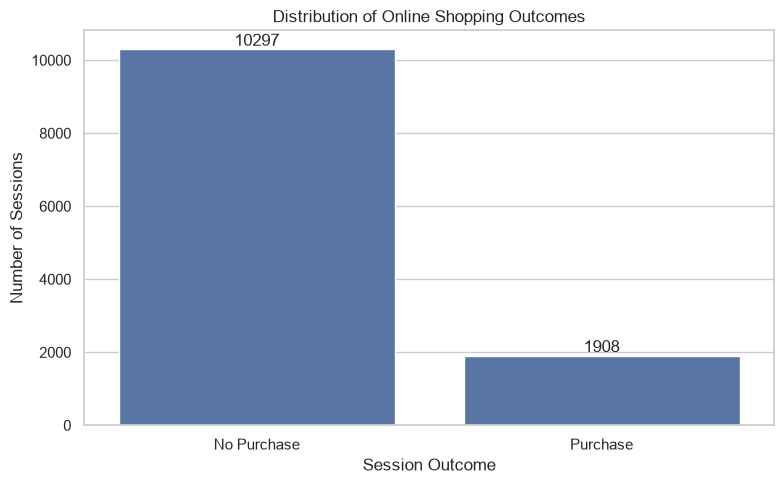

In [43]:
# Create clearer labels for the Revenue values.
revenue_plot_data = data.copy()

revenue_plot_data["Purchase Outcome"] = (
    revenue_plot_data["Revenue"]
    .map({
        False: "No Purchase",
        True: "Purchase"
    })
)

# Create a count plot of purchasing outcomes.
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=revenue_plot_data,
    x="Purchase Outcome"
)

# Display the count above each bar.
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Online Shopping Outcomes")
plt.xlabel("Session Outcome")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

In [44]:
# Calculate the count and percentage of each outcome.
revenue_counts = (
    data["Revenue"]
    .value_counts()
    .reindex([False, True])
)

revenue_percentages = (
    data["Revenue"]
    .value_counts(normalize=True)
    .reindex([False, True])
    .mul(100)
    .round(2)
)

# Create the summary table.
revenue_summary = pd.DataFrame({
    "Session Count": revenue_counts,
    "Percentage": revenue_percentages
})

# Replace Boolean index values with readable labels.
revenue_summary.index = [
    "No Purchase",
    "Purchase"
]

display(revenue_summary)

,Session Count,Percentage
No Purchase,10297,84.37
Purchase,1908,15.63


### Revenue Distribution Insight

The cleaned dataset contains 10,297 non-purchasing sessions and 1,908 purchasing sessions. Therefore, 84.37% of the sessions did not generate revenue, while only 15.63% resulted in a purchase.

This distribution confirms that Revenue is an imbalanced classification target. During Deliverable 3, classification performance should not be evaluated using accuracy alone. F1 score, confusion matrices, ROC curves, stratified data splitting, and possible class weighting will also be considered.

### B. Numerical Feature Distributions

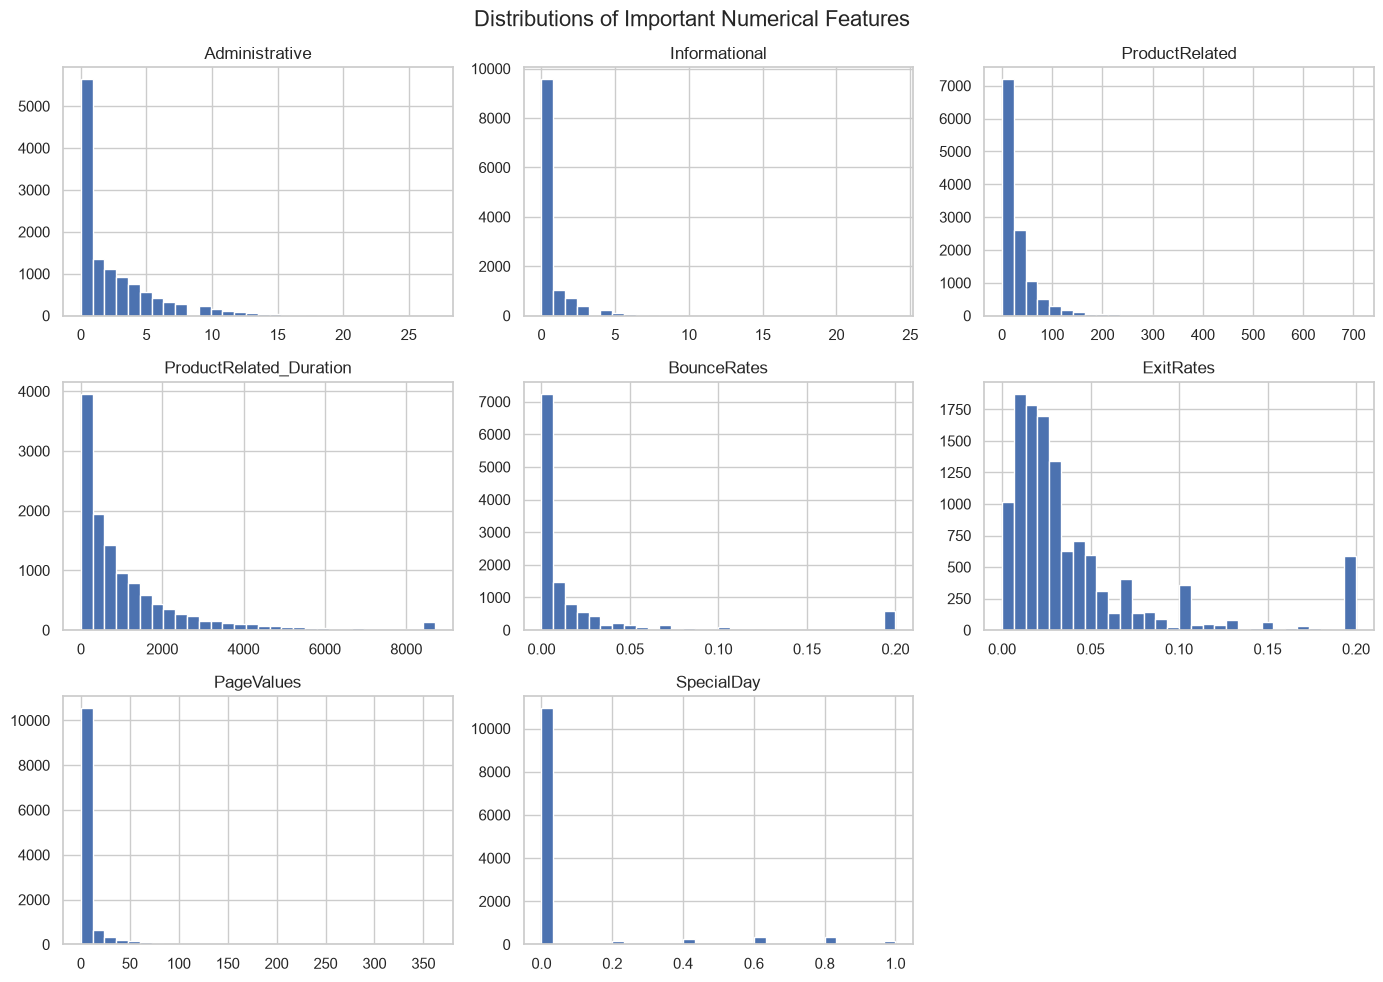

In [45]:
# Select important numerical variables for distribution analysis.
distribution_columns = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

# Create histograms for the selected variables.
data[distribution_columns].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle(
    "Distributions of Important Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Numerical Distribution Insights

The histograms show that most behavioral variables are strongly right-skewed.

Administrative and Informational contain many zero or low values, showing that many customers did not visit these page categories. ProductRelated contains higher values than the other page-count variables because product pages are the main focus of online shopping sessions.

ProductRelated_Duration also contains a long right tail. Most sessions were relatively short, while a smaller number of customers spent substantially more time examining product pages.

BounceRates and ExitRates were concentrated near zero but included some larger observations. PageValues contained many zero values because most sessions did not produce a purchase. SpecialDay also contained mostly zero values, meaning most sessions did not occur close to a special shopping date.

These distributions indicate that scaling and possible logarithmic transformations should be considered during later modeling.

### C. Duration Outliers

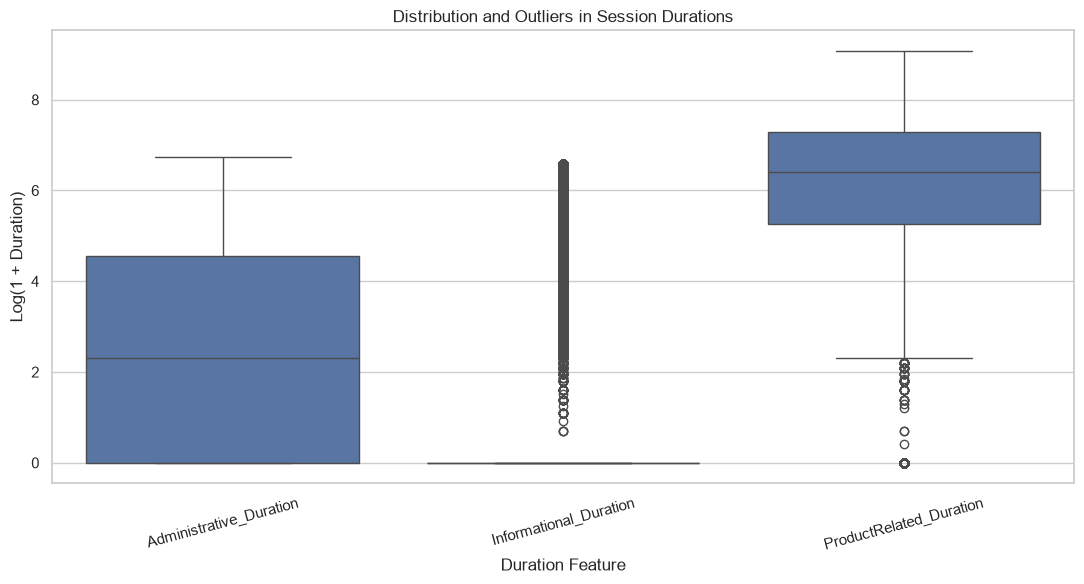

In [47]:
# Select the original duration measurements
# before the capping process.
duration_plot_data = data_before_capping[
    duration_columns
].copy()

# Apply log(1 + value) so that zero values remain valid
# and large observations are easier to visualize.
for column in duration_columns:
    duration_plot_data[column] = np.log1p(
        duration_plot_data[column]
    )

# Convert the data into long format.
duration_plot_data = duration_plot_data.melt(
    var_name="Duration Feature",
    value_name="Log Duration"
)

# Create the boxplot.
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=duration_plot_data,
    x="Duration Feature",
    y="Log Duration"
)

plt.title("Distribution and Outliers in Session Durations")
plt.xlabel("Duration Feature")
plt.ylabel("Log(1 + Duration)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Duration Outlier Insight

The log-transformed boxplot shows that all three duration variables are right-skewed. Administrative_Duration contains many zero-duration sessions but also several longer observations. Informational_Duration is concentrated at zero because most sessions did not include informational-page activity; consequently, many legitimate nonzero observations appear as statistical outliers. ProductRelated_Duration has the highest typical duration and the widest overall range, confirming that customers generally spend more time viewing product pages.

These unusual values were not treated as automatic errors. Only observations above the 99th percentile were capped, while the remaining values were preserved as potentially valid customer behavior.

### D. Correlation Analysis

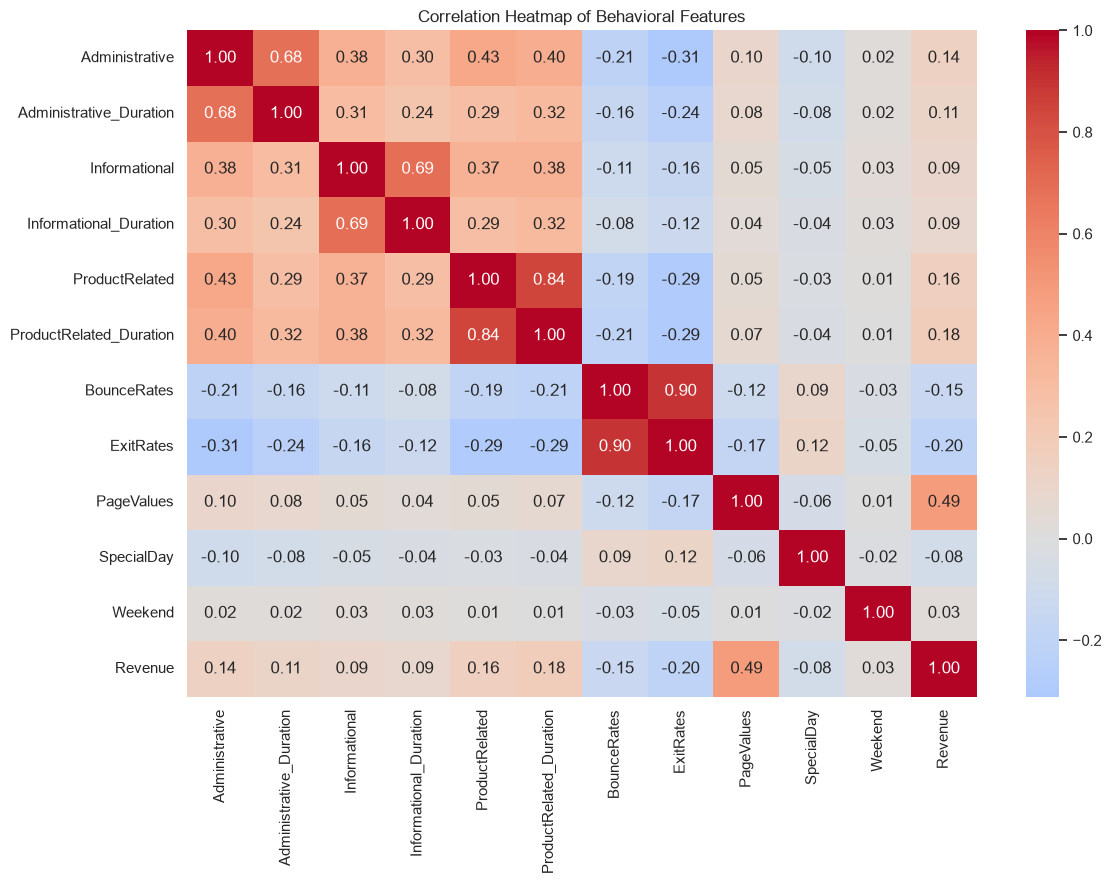

In [48]:
# Select numerical behavioral variables that have
# meaningful quantitative values.
correlation_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Weekend",
    "Revenue"
]

# Create a separate dataset for correlation analysis.
correlation_data = data[correlation_columns].copy()

# Convert Boolean columns into 0 and 1.
correlation_data["Weekend"] = (
    correlation_data["Weekend"].astype(int)
)

correlation_data["Revenue"] = (
    correlation_data["Revenue"].astype(int)
)

# Calculate the correlation matrix.
correlation_matrix = correlation_data.corr()

# Create the correlation heatmap.
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Behavioral Features")
plt.tight_layout()
plt.show()

In [49]:
# Display correlations with Revenue separately.
revenue_correlations = (
    correlation_matrix["Revenue"]
    .drop("Revenue")
    .sort_values(ascending=False)
    .to_frame(name="Correlation with Revenue")
)

display(revenue_correlations.round(3))

,Correlation with Revenue
PageValues,0.492
ProductRelated_Duration,0.175
ProductRelated,0.156
Administrative,0.136
Administrative_Duration,0.110
Informational,0.094
Informational_Duration,0.087
Weekend,0.028
SpecialDay,-0.084
BounceRates,-0.145


### Correlation Insights

PageValues had the strongest positive correlation with Revenue at 0.492, indicating that sessions with higher page values were substantially more likely to produce a purchase. ProductRelated_Duration and ProductRelated had smaller positive correlations of 0.175 and 0.156, respectively. Administrative activity also had a modest positive relationship with Revenue.

ExitRates had the strongest negative relationship with Revenue at approximately -0.20, followed by BounceRates at -0.145. This indicates that sessions with higher abandonment behavior were less likely to result in a purchase. Weekend had only a very weak positive correlation of 0.028, while SpecialDay had a weak negative correlation of -0.084.

The heatmap also identified strong relationships between ProductRelated and ProductRelated_Duration at 0.84, and between BounceRates and ExitRates at 0.90. These relationships indicate possible multicollinearity that should be considered during regression modeling.

### E. Conversion Rate by Visitor Type

In [50]:
# Calculate sessions, purchases, and conversion rates
# for each visitor type.
visitor_summary = (
    data.groupby(
        "VisitorType",
        observed=True
    )["Revenue"]
    .agg(["count", "sum", "mean"])
)

visitor_summary.columns = [
    "Sessions",
    "Purchases",
    "Conversion Rate"
]

# Convert the conversion rate into a percentage.
visitor_summary["Conversion Rate"] = (
    visitor_summary["Conversion Rate"] * 100
).round(2)

# Sort from highest to lowest conversion rate.
visitor_summary = visitor_summary.sort_values(
    by="Conversion Rate",
    ascending=False
)

display(visitor_summary)

,Sessions,Purchases,Conversion Rate
VisitorType,,,
New_Visitor,1693,422,24.93
Other,81,16,19.75
Returning_Visitor,10431,1470,14.09


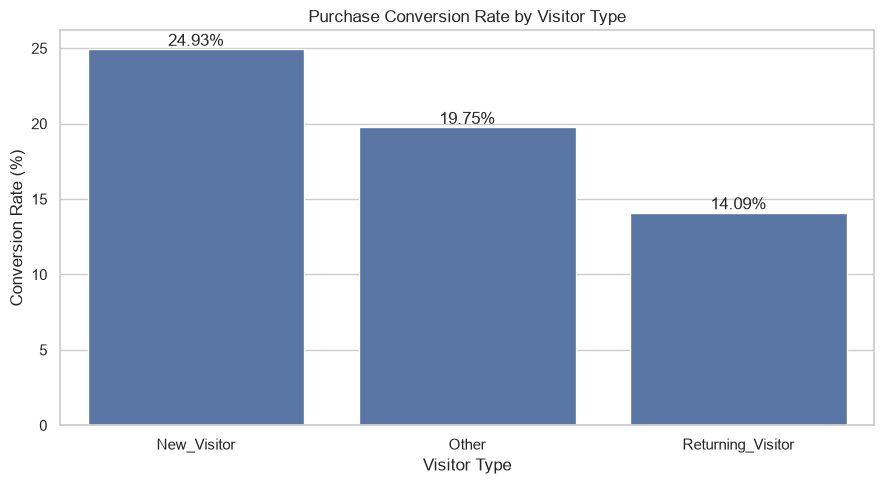

In [51]:
# Prepare the visitor summary for plotting.
visitor_plot_data = visitor_summary.reset_index()

# Create the visitor-type conversion graph.
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=visitor_plot_data,
    x="VisitorType",
    y="Conversion Rate",
    errorbar=None
)

# Display each percentage above its bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Purchase Conversion Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

### Visitor-Type Insight

New visitors had the highest conversion rate at 24.93%, producing 422 purchases from 1,693 sessions. Visitors classified as Other had a conversion rate of 19.75%, although this category contained only 81 sessions.

Returning visitors had the lowest conversion rate at 14.09%. However, they produced 1,470 purchases because they represented 10,431 of the 12,205 cleaned sessions.

Visitor type should therefore not be interpreted using conversion percentage alone. New visitors converted at a higher rate, but returning visitors generated most purchases because of their much larger session volume.

### F. Monthly Conversion Rate

In [52]:
# Calculate sessions, purchases, and conversion rates by month.
monthly_summary = (
    data.groupby(
        "Month",
        observed=True
    )["Revenue"]
    .agg(["count", "sum", "mean"])
)

monthly_summary.columns = [
    "Sessions",
    "Purchases",
    "Conversion Rate"
]

# Convert the conversion rate into a percentage.
monthly_summary["Conversion Rate"] = (
    monthly_summary["Conversion Rate"] * 100
).round(2)

# Keep the results in chronological order.
monthly_summary = monthly_summary.reindex(
    month_order
)

display(monthly_summary)

,Sessions,Purchases,Conversion Rate
Month,,,
Feb,181,3,1.66
Mar,1860,192,10.32
May,3329,365,10.96
June,285,29,10.18
Jul,432,66,15.28
Aug,433,76,17.55
Sep,448,86,19.20
Oct,549,115,20.95
Nov,2982,760,25.49


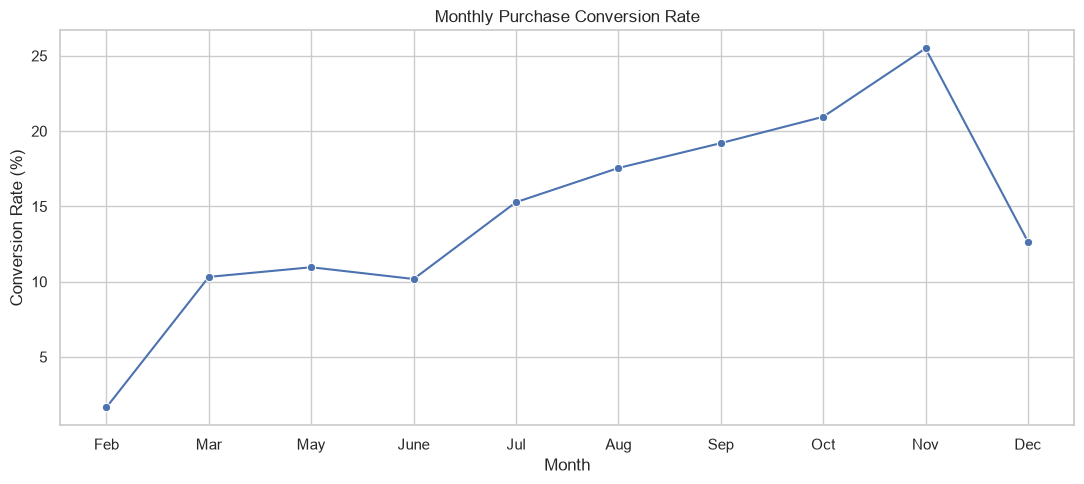

In [33]:
# Create a line chart of monthly conversion rates.
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=monthly_summary.reset_index(),
    x="Month",
    y="Conversion Rate",
    marker="o"
)

plt.title("Monthly Purchase Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

### Monthly Insight

Monthly conversion rates varied considerably across the dataset.

November had the highest conversion rate at 25.49%, producing 760 purchases from 2,982 sessions. October had the second-highest rate at 20.95%, followed by September at 19.20%.

February had the lowest conversion rate at only 1.66%, with 3 purchases from 181 sessions. March, May, and June had similar conversion rates of approximately 10%.

The increase during September, October, and November suggests that purchasing behavior may be affected by seasonal shopping activity and promotional events. However, January and April are not present in the dataset, so the results should not be interpreted as a complete twelve-month seasonal analysis.

### G. Weekday and Weekend Conversion Rate

In [53]:
# Compare weekday and weekend purchasing behavior.
weekend_summary = (
    data.groupby("Weekend")["Revenue"]
    .agg(["count", "sum", "mean"])
)

weekend_summary.columns = [
    "Sessions",
    "Purchases",
    "Conversion Rate"
]

# Convert the conversion rate into a percentage.
weekend_summary["Conversion Rate"] = (
    weekend_summary["Conversion Rate"] * 100
).round(2)

# Replace Boolean labels with readable labels.
weekend_summary = weekend_summary.rename(
    index={
        False: "Weekday",
        True: "Weekend"
    }
)

display(weekend_summary)

,Sessions,Purchases,Conversion Rate
Weekend,,,
Weekday,9346,1409,15.08
Weekend,2859,499,17.45


,Session Period,Sessions,Purchases,Conversion Rate
0,Weekday,9346,1409,15.08
1,Weekend,2859,499,17.45


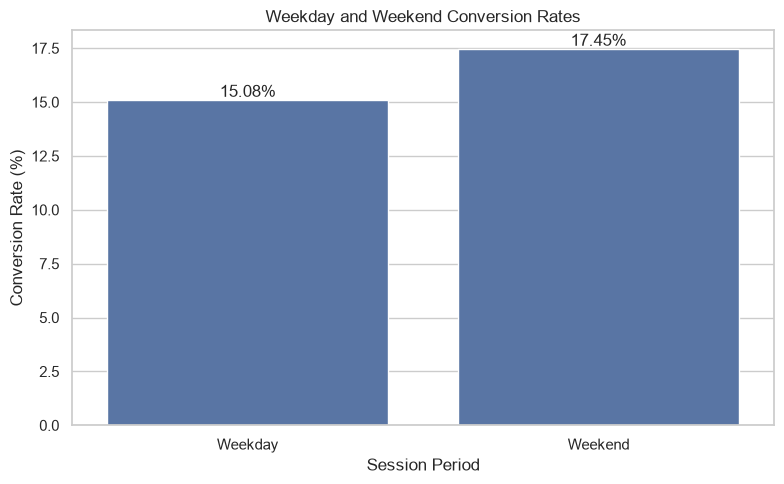

In [54]:
# Reset the index so Weekday and Weekend become a regular column.
weekend_plot_data = weekend_summary.reset_index()

# Rename the Weekend column to a clearer graph label.
weekend_plot_data = weekend_plot_data.rename(
    columns={"Weekend": "Session Period"}
)

# Display the prepared data to confirm the column names.
display(weekend_plot_data)

# Create the conversion-rate comparison graph.
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=weekend_plot_data,
    x="Session Period",
    y="Conversion Rate"
)

# Display each conversion rate above its bar.
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Weekday and Weekend Conversion Rates")
plt.xlabel("Session Period")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

### Weekend Insight

The dataset contains 9,346 weekday sessions and 2,859 weekend sessions. Weekday sessions generated 1,409 purchases, while weekend sessions generated 499 purchases.

Weekend sessions had a conversion rate of 17.45%, compared with 15.08% for weekday sessions. Therefore, an individual weekend session was slightly more likely to result in a purchase.

However, most total purchases occurred during weekdays because the dataset contained substantially more weekday sessions. Weekend status may provide useful predictive information when combined with month, visitor type, and browsing activity.

### H. Engagement by Purchase Outcome

In [55]:
# Select important customer-engagement measurements.
engagement_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

# Calculate the average of each feature
# for purchasing and non-purchasing sessions.
engagement_summary = (
    data.groupby("Revenue")[engagement_columns]
    .mean()
    .round(3)
)

# Replace Boolean labels with readable labels.
engagement_summary = engagement_summary.rename(
    index={
        False: "No Purchase",
        True: "Purchase"
    }
)

display(engagement_summary)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
Revenue,,,,,,,,,
No Purchase,2.143,70.268,0.457,26.753,29.05,1047.250,0.023,0.046,2.000
Purchase,3.394,113.451,0.786,51.970,48.21,1797.834,0.005,0.020,27.265


### Customer Engagement Insights

Purchasing sessions demonstrated substantially greater engagement than non-purchasing sessions.

Purchasing sessions visited an average of 3.394 administrative pages, compared with 2.143 for non-purchasing sessions. They also spent an average of 113.451 units of time on administrative pages, compared with 70.268.

Purchasing sessions visited an average of 0.786 informational pages and spent 51.97 units of time on them. Non-purchasing sessions visited 0.457 informational pages and spent 26.753 units of time on average.

The strongest behavioral differences appeared in product-related activity. Purchasing sessions visited an average of 48.21 product-related pages and spent 1,797.834 units of time on them. Non-purchasing sessions visited 29.05 product-related pages and spent 1,047.25 units of time.

Purchasing sessions also had lower abandonment measurements. Their average BounceRates value was 0.005, compared with 0.023 for non-purchasing sessions. Their average ExitRates value was 0.02, compared with 0.046.

The largest difference occurred in PageValues. Purchasing sessions had an average PageValues measurement of 27.265, while non-purchasing sessions had an average of only 2.000.

## I. PageValues by Purchase Outcome

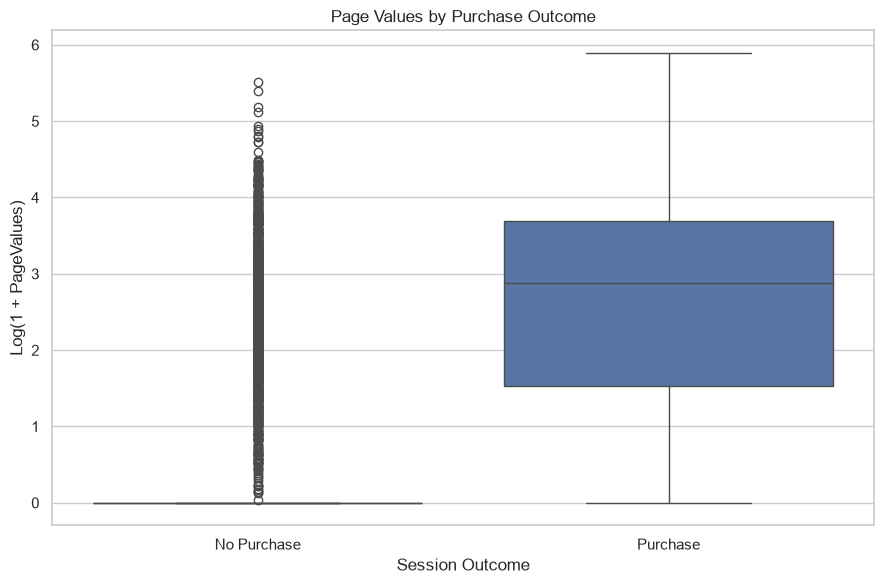

In [56]:
# Create a separate copy for the PageValues graph.
page_value_plot_data = data.copy()

# Create readable purchase labels.
page_value_plot_data["Purchase Outcome"] = (
    page_value_plot_data["Revenue"]
    .map({
        False: "No Purchase",
        True: "Purchase"
    })
)

# Apply log(1 + PageValues) to preserve zero values
# and make the skewed distribution easier to display.
page_value_plot_data["Log PageValues"] = np.log1p(
    page_value_plot_data["PageValues"]
)

# Create the boxplot.
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=page_value_plot_data,
    x="Purchase Outcome",
    y="Log PageValues"
)

plt.title("Page Values by Purchase Outcome")
plt.xlabel("Session Outcome")
plt.ylabel("Log(1 + PageValues)")
plt.tight_layout()
plt.show()

### PageValues by Purchase Outcome Insight

The log-transformed boxplot shows a clear difference in PageValues between the two purchase outcomes. Most non-purchasing sessions had PageValues equal to zero, although some non-purchasing sessions contained higher values and appeared as outliers.

Purchasing sessions generally had substantially higher PageValues, with a much higher median and wider central distribution. Some purchasing sessions still had PageValues of zero, so PageValues does not perfectly separate the two outcomes. However, the graph strongly supports the earlier finding that higher PageValues are associated with a greater likelihood of purchase.

### J. Product Duration and PageValues

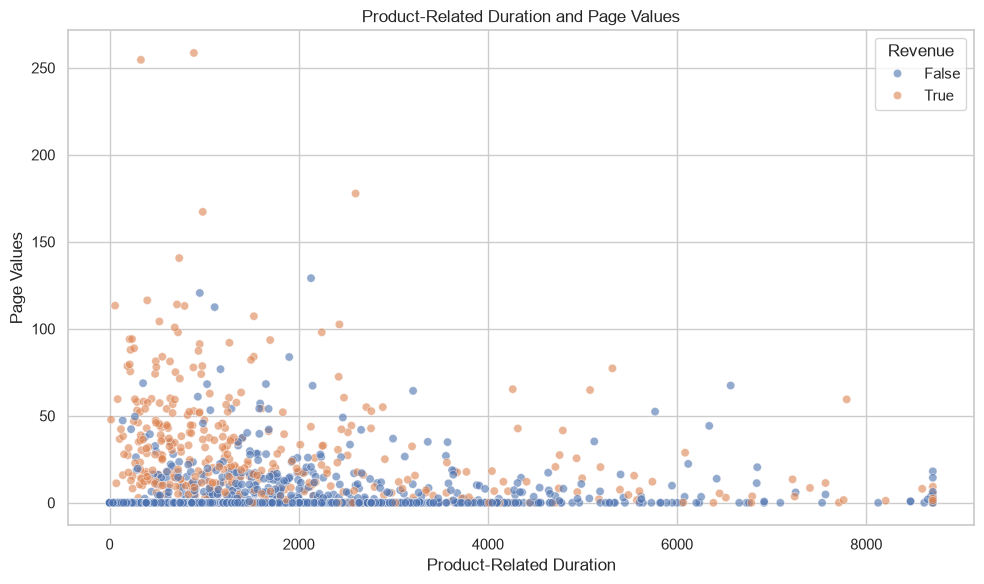

In [57]:
# Sample up to 3,000 records to keep the scatterplot readable.
scatter_sample = data.sample(
    n=min(3000, len(data)),
    random_state=42
)

# Create a scatterplot comparing product duration
# with PageValues and purchase outcome.
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="ProductRelated_Duration",
    y="PageValues",
    hue="Revenue",
    alpha=0.6
)

plt.title("Product-Related Duration and Page Values")
plt.xlabel("Product-Related Duration")
plt.ylabel("Page Values")
plt.tight_layout()
plt.show()

### Product Duration and PageValues Insight

The scatterplot shows that ProductRelated_Duration alone does not clearly separate purchasing and non-purchasing sessions. Many sessions had PageValues near zero even when customers spent a long time viewing product pages.

Purchasing sessions were more common among observations with moderate-to-high PageValues, particularly when customers also spent meaningful time on product-related pages. However, both purchase outcomes overlap across most product-duration values.

This indicates that longer product browsing may support purchasing behavior, but it is not sufficient by itself. Future models should combine ProductRelated_Duration with PageValues, product-page counts, bounce rates, exit rates, visitor type, and seasonal features.

## Saving the Cleaned Dataset

The cleaned dataset is saved so that the same records and cleaning decisions can be used throughout Deliverables 2 and 3.

In [58]:
# Save the cleaned dataset without including
# the Pandas index as another column.
data.to_csv(
    "online_shoppers_cleaned.csv",
    index=False
)

print(
    "The cleaned dataset was saved as "
    "'online_shoppers_cleaned.csv'."
)

The cleaned dataset was saved as 'online_shoppers_cleaned.csv'.


In [59]:
# Confirm that the saved dataset can be loaded correctly.
cleaned_data_check = pd.read_csv(
    "online_shoppers_cleaned.csv"
)

print(
    "Saved dataset shape:",
    cleaned_data_check.shape
)

cleaned_data_check.head()

Saved dataset shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Major Insights from Exploratory Data Analysis

The cleaned dataset contains 12,205 unique online shopping sessions. Of these sessions, 10,297, or 84.37%, did not result in a purchase. Only 1,908 sessions, or 15.63%, generated revenue. This confirms that the classification target is imbalanced.

PageValues had the strongest positive correlation with Revenue at approximately 0.49. Purchasing sessions had an average PageValues measurement of 27.265, compared with only 2.000 for non-purchasing sessions.

Product-related behavior also differed considerably between the two outcomes. Purchasing sessions visited an average of 48.21 product-related pages and spent 1,797.836 units of time on them. Non-purchasing sessions visited an average of 29.05 product-related pages and spent 1,047.25 units of time.

Purchasing sessions had lower abandonment measurements. Their average BounceRates value was 0.005, compared with 0.023 for non-purchasing sessions. Their average ExitRates value was 0.020, compared with 0.046.

New visitors had the highest conversion rate at 24.93%, while returning visitors had a conversion rate of 14.09%. However, returning visitors generated 1,470 purchases because they represented most of the sessions.

November had the highest monthly conversion rate at 25.49%, followed by October at 20.95% and September at 19.20%. February had the lowest conversion rate at 1.66%.

Weekend sessions had a conversion rate of 17.45%, compared with 15.08% for weekday sessions. Nevertheless, weekdays generated more total purchases because they contained substantially more sessions.

Overall, the results indicate that purchasing behavior is associated with higher page value, greater product engagement, longer browsing durations, and lower bounce and exit rates.

## Preparation for Future Deliverables

The cleaned dataset will continue to be used throughout the project.

For Deliverable 2, PageValues will be used as the continuous regression target. At least two regression models, including Linear Regression and Ridge Regression, will be evaluated. Revenue will not be included as a regression predictor because it represents the final purchasing outcome and could introduce target leakage.

Feature engineering may include total page visits, total session duration, average duration per page, product-engagement ratios, and logarithmic transformations for skewed variables. Categorical variables will be encoded before model training.

For Deliverable 3, Revenue will be used as the classification target. At least two classification models will be developed, and one model will undergo hyperparameter tuning. Stratified data splitting and class-sensitive evaluation will be used because Revenue is imbalanced.

Clustering will use standardized behavioral variables such as page counts, duration measurements, bounce rates, exit rates, and PageValues to identify groups of sessions with similar browsing behavior.

Association rule mining will be performed by transforming continuous variables into categorical items such as High_Product_Activity, Long_Product_Duration, Low_Exit_Rate, New_Visitor, Weekend, November, and Purchase.

## Challenges Encountered

One challenge was that the dataset did not contain missing values. Although no imputation was necessary, every column was still checked and documented to confirm that missing data would not affect the analysis.

A second challenge was the presence of 125 exact duplicate records. These records were removed so that repeated observations would not influence distributions, conversion rates, correlations, or later models.

Another challenge was distinguishing noisy data from legitimate customer behavior. The IQR method identified many statistical outliers because several variables were strongly skewed and contained many zero values. Automatically removing all identified outliers would have removed useful customer sessions. Therefore, only the most extreme values in the three duration columns were capped.

The numerical attributes Browser, OperatingSystems, Region, and TrafficType were also initially treated as numerical measurements. However, their values represent category codes. They were therefore excluded from the final outlier and Pearson correlation analyses.

The final challenge was the imbalance in the Revenue target. Most sessions did not result in a purchase. The original distribution was preserved because it represents actual customer behavior. This issue will be addressed through stratified splitting and appropriate classification metrics in Deliverable 3.

## Conclusion

The Online Shoppers Purchasing Intention Dataset was successfully loaded, inspected, cleaned, and explored. The original dataset contained 12,330 shopping sessions and 18 columns. No missing values, negative numerical values, or invalid rate values were found.

A total of 125 exact duplicate records were removed. Extreme values in Administrative_Duration, Informational_Duration, and ProductRelated_Duration were capped at their 99th-percentile limits while preserving all unique customer sessions.

Exploratory analysis showed that purchasing sessions generally had greater page engagement, higher PageValues, longer product-related browsing time, and lower bounce and exit rates. The analysis also identified class imbalance, seasonal conversion differences, visitor-type differences, and a slightly higher conversion rate during weekends.

The final cleaned dataset contains 12,205 unique sessions and is ready for regression, classification, clustering, association rule mining, and the final project analysis.